## 케글 수어 데이터셋
- 미국 수어(ASL, American Sign Language)의 알파벳 손짓을 $28 \times 28$ 흑백 이미지 형태의 수치 데이터로 변환한 데이터셋입니다.
- 포함 라벨: A, B, C, D, E, F, G, H, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y
    - 제외된 라벨 (J, Z):
    - 알파벳 J와 Z는 정적인 손 모양이 아니라 손가락을 움직이는 동작(Motion)이 포함되어야 표현되는 수어입니다.
    - 단일 정지 이미지로는 표현할 수 없어 데이터셋에서 완전히 제외되었습니다. (라벨 9번과 25번이 비어 있음)

[케글 수어 데이터셋](https://www.kaggle.com/datasets/datamunge/sign-language-mnist)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

import torch
import torch.nn as nn
import torch.optim as optim

import sklearn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 데이터를 가져오는 모듈
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, Dataset, DataLoader

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

sklearn.set_config(display="text")

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: cuda


In [3]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
train_file_name = r"sign_mnist_train.csv"
test_file_name = r"sign_mnist_test.csv"

train_file_path = os.path.join(base_path, train_file_name)
test_file_path = os.path.join(base_path, test_file_name)

train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

In [4]:
print(train_df.head(1))
print(test_df.head(1))

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   

   pixel781  pixel782  pixel783  pixel784  
0       206       204       203       202  

[1 rows x 785 columns]
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      6     149     149     150     150     150     151     151     150   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     151  ...       138       148       127        89        82        96   

   pixel781  pixel782  pixel783  pixel784  
0       106       112       120       107  

[1 rows x 785 columns]


In [5]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [6]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(27455, 784) (27455,)
(7172, 784) (7172,)


In [7]:
len(pd.Series(y_train).unique())

24

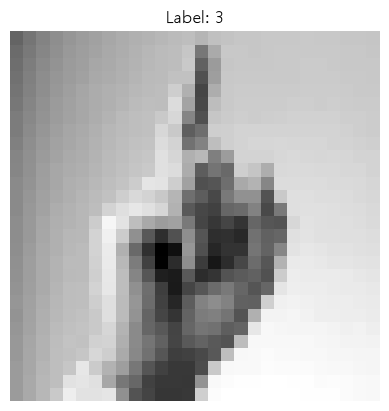

In [8]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [9]:
import string

In [10]:
classes_dict = {}
idx = 0
for char in string.ascii_uppercase:
    if char in ["J", "Z"]:
        continue
    classes_dict[idx] = char
    idx += 1 if char != "I" else 2

print(classes_dict)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}


## 데이터 증강 실습 ----------------------------------------------------------------------------

In [12]:
X_train
y_train
# 텐서형태가 아니라 넘파이 어레이임! 이 친구들을 텐서로 바꿔주자 

array([ 3,  6,  2, ..., 18, 17, 23], shape=(27455,))

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) / 255.0
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 형변화와 동시에 정규화 

## TensorDataset 준비

In [15]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
# 나눠서 담기

## 데이터 증강

In [16]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0), # 무조건 좌우반전
    transforms.RandomVerticalFlip(p=0.5), # 50퍼 확률로 상하반전
    transforms.RandomRotation(degrees=(90, 90))
])

In [17]:
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    #오버라이딩
    def __getitem__(self, idx):
        x, y = self.dataset[idx] # 데이터셋 순서대로 받아와서 x,y에 담기
        
        if self.transform:
            x = x.view(28, 28).unsqueeze(0) # view(원본데이터 복사해서 리턴) 그리고 언스퀴지?? 모름
            x = self.transform(x)
            x = x.flatten()

        return x, y

In [20]:
train_aug_dataset = AugmentedDataset(train_dataset, train_transform) # 통과함과 동시에 증가된? 데이터임

## 데이터 로더(DataLoader)

In [22]:
train_loader = DataLoader(train_aug_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [23]:
imgs, labels = next(iter(train_loader)) #train_loader에서 첫 번째 batch를 가져옴.

print(imgs)
print(labels)

# iter() → 반복할 수 있는 형태로 만듦
# next() → 거기서 다음 데이터 1개 가져옴

tensor([[0.6118, 0.6118, 0.6235,  ..., 0.7216, 0.7647, 0.7137],
        [0.4000, 0.4039, 0.4078,  ..., 0.7569, 0.7490, 0.7412],
        [0.8078, 0.8157, 0.8235,  ..., 0.6510, 0.7059, 0.6431],
        ...,
        [0.3529, 0.3294, 0.3059,  ..., 0.5098, 0.5412, 0.5216],
        [0.5020, 0.5020, 0.5059,  ..., 0.5294, 0.5216, 0.5176],
        [0.3922, 0.4000, 0.3961,  ..., 0.7451, 0.7412, 0.7294]])
tensor([ 1, 19, 23, 19,  0, 10,  3, 10, 24, 24,  0,  8, 15, 22, 16,  8,  2, 22,
         1, 16,  0,  7, 13, 21,  5, 10, 17, 16, 11,  8,  2, 19, 21,  1, 15,  7,
        10,  5,  2, 10,  1,  1,  3,  6,  5, 12, 12, 19, 12, 11, 17,  6,  3, 10,
        21,  7,  5,  0,  0, 22, 15, 16, 19, 19])


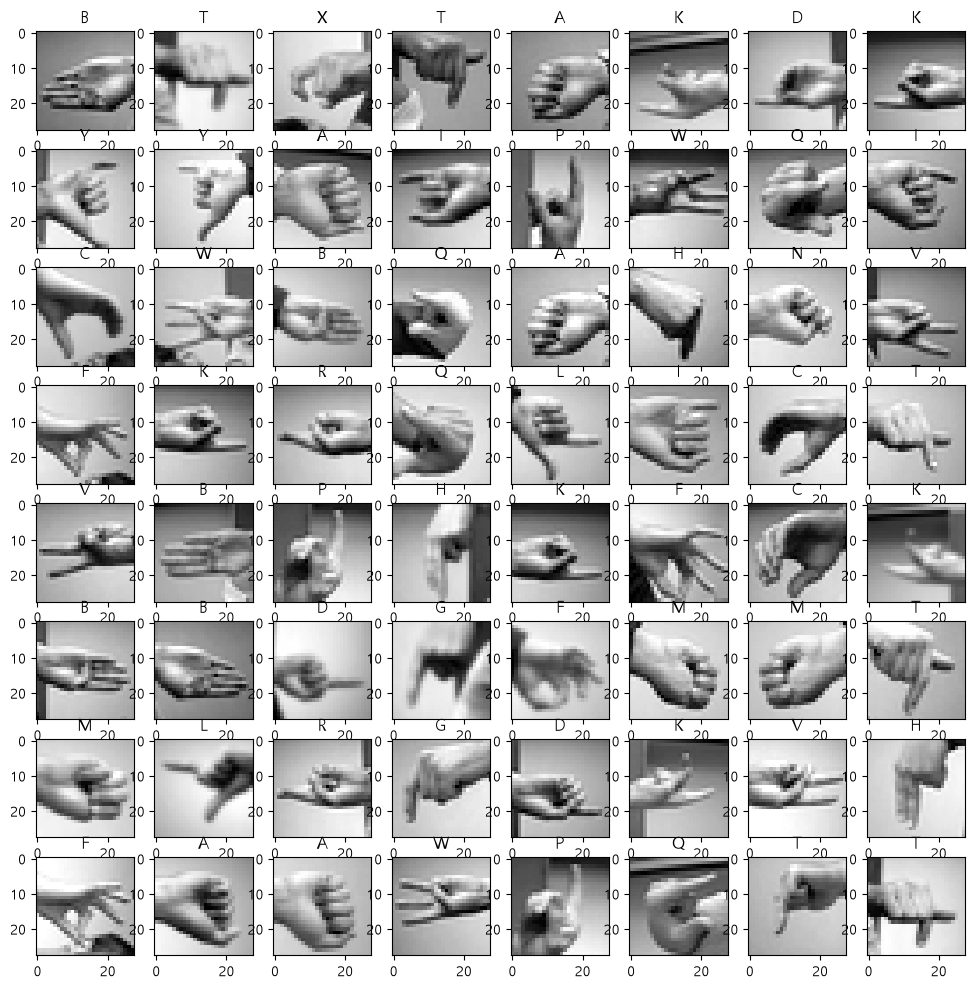

In [27]:
plt.figure(figsize=(12,12))

for i in range(len(imgs)):
    plt.subplot(8, 8, i + 1)
    img = imgs[i].view(28, 28).numpy()
    plt.imshow(img, cmap="gray")
    plt.title(classes_dict[labels[i].item()])

plt.show()

## 모델준비 

In [28]:
model = nn.Sequential(
    nn.Linear(28 * 28, 25) #입력데이터와 출력데이터 (왜 28*28이고 25출력인가?? a부터z 까지 결과물이 24개이기때문. 근데 번호가 0부터니께 25개)
)

In [34]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [37]:
def train_one_epoch(model, dataloader, criterion, optimizer, device="cpu"): # 왜 함수로 만들었는가? 쉬울라고.
    model.train() #모델 학습모델로 바뀌어야함

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # 디바이스쪽으로 보내놔도됨

        #학습시작!
        optimizer.zero_grad() # 최적의 파라미터를 구해주는 랜덤값부터 시작하겟다. 이제부터 0이다.!!!!!!!!
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) 
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트 

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc #평균 구한겨?

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)

    return avg_loss, avg_acc

## 모델 평가

In [38]:
@torch.no_grad() # 토치는 자동으로 미분? 을 하는데 그게 필요없을땐 비효율적이기때문에 이걸 걸어서 멈추기? (데코레이터 라고 부름 @) ## 미분 계산 x라는 뜻
def evaluate(model, dataloader, criterion, device="cpu"): # 옵티제거
    model.eval() #평가모드로 바꾸기

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) 

        #평가시작!
        # optimizer.zero_grad() # 평가할때는 파라미터 건드리지 않음
        y_pred = model(X_batch) 
        loss = criterion(y_pred, y_batch) 
        # loss.backward() # 노필요
        # optimizer.step() # 노필요

        sum_losses += loss
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc 

    avg_loss = sum_losses / len(dataloader)
    avg_acc = sum_accs / len(dataloader)

    return avg_loss, avg_acc

In [40]:
epochs = 50

for epoch in range(epochs):
    avg_loss, avg_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    print(f"Epoch: {epoch + 1}/{epochs} | Loss: {avg_loss:.2f} | Accuracy: {avg_acc: .2f}%")

Epoch: 1/50 | Loss: 2.66 | Accuracy:  25.29%
Epoch: 2/50 | Loss: 2.12 | Accuracy:  42.06%
Epoch: 3/50 | Loss: 1.89 | Accuracy:  48.24%
Epoch: 4/50 | Loss: 1.74 | Accuracy:  52.01%
Epoch: 5/50 | Loss: 1.63 | Accuracy:  54.61%
Epoch: 6/50 | Loss: 1.55 | Accuracy:  56.73%
Epoch: 7/50 | Loss: 1.48 | Accuracy:  58.68%
Epoch: 8/50 | Loss: 1.43 | Accuracy:  60.34%
Epoch: 9/50 | Loss: 1.37 | Accuracy:  62.16%
Epoch: 10/50 | Loss: 1.34 | Accuracy:  62.90%
Epoch: 11/50 | Loss: 1.29 | Accuracy:  64.32%
Epoch: 12/50 | Loss: 1.26 | Accuracy:  65.47%
Epoch: 13/50 | Loss: 1.23 | Accuracy:  66.52%
Epoch: 14/50 | Loss: 1.20 | Accuracy:  67.47%
Epoch: 15/50 | Loss: 1.17 | Accuracy:  68.03%
Epoch: 16/50 | Loss: 1.14 | Accuracy:  69.20%
Epoch: 17/50 | Loss: 1.13 | Accuracy:  69.65%
Epoch: 18/50 | Loss: 1.11 | Accuracy:  70.30%
Epoch: 19/50 | Loss: 1.08 | Accuracy:  71.08%
Epoch: 20/50 | Loss: 1.06 | Accuracy:  71.21%
Epoch: 21/50 | Loss: 1.04 | Accuracy:  72.06%
Epoch: 22/50 | Loss: 1.02 | Accuracy:  72.6

In [41]:
avg_loss, avg_acc = evaluate(model, train_loader, criterion)
print(f"Test Loss: {avg_loss:.4f} | Test Accuracy: {avg_acc: .2f}%")

Test Loss: 0.7251 | Test Accuracy:  81.37%


## 잘못된 데이터 증강은 오히려 과소적합을 발생시킬 수 있다.